# Конструирование алгоритмов mclp

In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import geopandas as gpd
from genesis.core import BestPointsBase, MetricBase, StateBase
from genesis.best_points import BestNodeHillClimbing
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.tools import list_dict_concat
from genesis.utils import timing
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import osmnx as ox

In [2]:
# Загрузка графа и полигона границ
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

In [7]:
cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])

def iter_state_func(**kwds):
    '''
    Печать состояния расчета на итерации
    '''
    # print('Итерация:', kwds['i'])
    print(kwds)
    dynamic_nodes = kwds['dynamic_nodes']
    if isinstance(dynamic_nodes, dict):
        dynamic_nodes_id = list(dynamic_nodes.keys())
    else:
        dynamic_nodes_id = dynamic_nodes

    try:
        static_nodes = kwds['static_nodes']
        if isinstance(static_nodes, dict):
            static_nodes_id = list(static_nodes.keys())
        else:
            static_nodes_id = static_nodes
    except:
        static_nodes = None
        
    if not static_nodes is None:
        if isinstance(dynamic_nodes,list):
            start_nodes = dynamic_nodes+static_nodes
        elif isinstance(dynamic_nodes,dict):
            start_nodes = {**dynamic_nodes, **static_nodes}
    else:
        start_nodes = dynamic_nodes
    times, nearest = FirstArrivalUnitState()(env=G, points=start_nodes)
    times = {k:(1+int(t//5))*5 for k, t in times.items()}

    nx.set_node_attributes(G, pd.Series(nearest, dtype=str), 'nearest')
    nx.set_node_attributes(G, times, 'route_time')

    nds = ox.graph_to_gdfs(G, edges=False)
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
    nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3', legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax1, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax1, markersize=25, color='k')

    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
    nds.plot(ax=ax2, markersize=2, column='route_time', cmap=cmap1, legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax2, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax2, markersize=25, color='k')

    plt.show()

def iter_func(**kwds):
    'Функция вывода хода расчета'
    print(kwds)

{'best_metric': 5.2880732710581775, 'dynamic_nodes': {1296599762: 'A', 2042076750: 'B', 2760591335: 'c', 4901942432: 'd'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 3.6553615287374672, 'dynamic_nodes': {426923835: 'A', 4116034584: 'B', 4116059950: 'c', 4901942432: 'd'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 3.3658501673478516, 'dynamic_nodes': {426923835: 'A', 2034401645: 'B', 4116059950: 'c', 4901942432: 'd'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 3.0613341835046937, 'dynamic_nodes': {426923872: 'A', 2034401381: 'B', 4116059950: 'c', 4901942432: 'd'}, 'static_nodes': {}}
{'i': 3, 'best_metric': 3.060101014209081, 'dynamic_nodes': {426923872: 'A', 2034401374: 'B', 4116059950: 'c', 4901942432: 'd'}, 'static_nodes': {}}
{'i': 4, 'best_metric': 3.060101014209081, 'dynamic_nodes': {426923872: 'A', 2034401374: 'B', 4116059950: 'c', 4901942432: 'd'}, 'static_nodes': {}}
ВРЕМЯ: 18.63 сек
{'dynamic_nodes': {426923872: 'A', 2034401374: 'B', 4116059950: 'c', 4901942432: 'd'}}


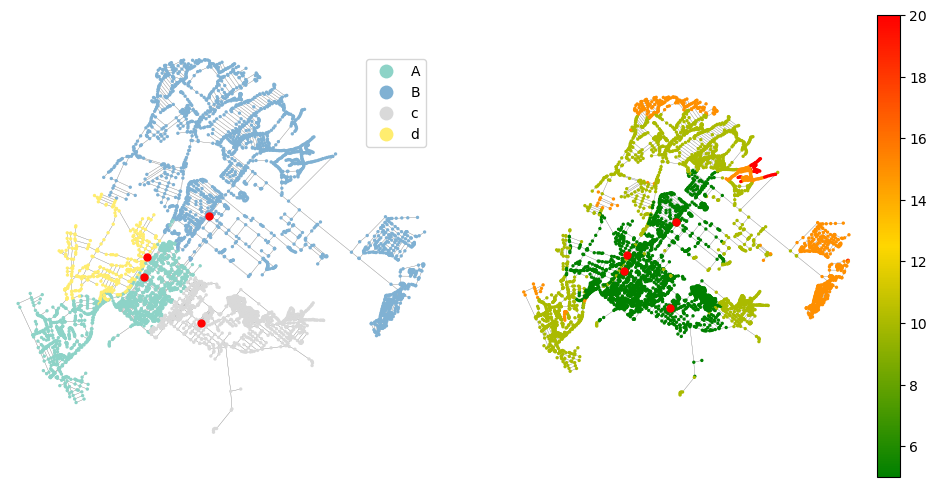

In [9]:
class BestNodesKoptG(BestPointsBase):
    '''
    Поиск лучших узлов для размещения n объектов.

    Расчет производится алгоритмом k-mean адаптированным для расчета
    в графовом пространстве и абстрагированным от применения метрики
    mean (среднее).

    ## Область применения
    Определение размещения множества узлов в графе, при котором 
    обеспечиваются наилучшие некоторые целевые метрики. 
    Дает достаточно точное решение. Хорошо подходит для больших графов.
    '''

    def __init__(self,
                 state_function: StateBase,
                 metric_function: MetricBase,
                 best_point_function: BestPointsBase,
                 iterations:int=5,
                 appr_val_in_area=0,
                 **kwargs) -> None:
        '''
        ## Аргументы
        `state_function`: StateBase
            функция расчета состояния окружения
        `metric_function`: MetricBase
            Функция расчета метрики
        `best_point_function`: BestPointsBase
            Функция расчета лучшего размещения узла
        `iterations`:int=5
            Количество итераций расчета
        `appr_val_in_area`: int=0
            Доля узлов графа в пределах area, покрытие которой считается приемлемой для принятия расчетной метрики. 
            Если при расчете метрик, из стартового узла (узлов) достижимо меньшее количество узлов,
            то такой узел не рассматривается.
            При расчет размещения нескольких узлов неминуемо возникает ситуация при которой
            часть территории area будет недостижима. Поэтому по умолчанию считается
        '''
        
        self.best_point_function = best_point_function
        self.iterations = iterations
        self.appr_val_in_area = appr_val_in_area
        super().__init__(state_function, metric_function, **kwargs)


    def __call__(self,
                 env:nx.MultiDiGraph,
                 dynamic_nodes: list|dict,
                 static_nodes: list|dict = None,
                 before_iters_start_function: callable =None,
                 iter_calc_end_function: callable =None,
                 area: pd.Series = None,
                 **kwargs):
        '''
        ## Аргументы

        `env`:nx.MultiDiGraph
            Граф улично-дорожной сети
        `dynamic_nodes`: list|dict
            Список стартовых узлов графа в которых размещены
            подразделения оптимальные места которых следует определить.
        `static_nodes`: list|dict = None
            Список стартовых узлов графа в которых размещены
            подразделения изменять размещение которых не следует.
        `before_iters_start_function`: callable=None
            Функция выполняемая перед началом итеративного расчета.
            Сигнатура функции:
            ```
            before_iters_start_function(
                                    best_metric: float,
                                    dynamic_nodes: list|dict,
                                    static_nodes: list|dict
                                    )
            ```
            Если не указана, ничего не происходит.
        `iter_calc_end_function`: callable=None
            Функция выполняемая в конце каждой итерации.
            Сигнатура функции:
            ```
            before_iters_start_function(
                                    best_metric: float,
                                    dynamic_nodes: list|dict,
                                    static_nodes: list|dict
                                    )
            ```
            Если не указана, ничего не происходит.
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.

        ## Возвращает
        `best_dynamic_nodes, best_metric`: tuple[list | dict, float]
            Список или словарь лучших мест размещения, значение метрики metric_function
            для лучшего размещения.
        '''
        
        # 0. Проверка корректности пришедших данных
        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип аргумента `env` должен быть MultiDiGraph!")
        if not static_nodes is None:
            if not ((isinstance(dynamic_nodes,list) and isinstance(static_nodes,list)) or \
                (isinstance(dynamic_nodes,dict) and isinstance(static_nodes,dict))):
                raise TypeError(f'Аргументы `dynamic_nodes` и `static_nodes` должны быть одинакового типа: list|dict'
                                f'Имеют: {type(dynamic_nodes)}, {type(static_nodes)}')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')

        # Если передана область которую следует учитывать в расчете
        # установить для нее приемлемый охват равный `self.appr_val_in_area`
        # (0 по умолчанию)
        if not area is None:
            self.best_point_function.__setattr__('appr_val',
                                                 self.appr_val_in_area)

        # 1.1. Если статические узлы не указаны - заменяем значение переменной с None
        # на [] или {} в зависимости от типа данных `dynamic_nodes`
        if static_nodes is None:
            if isinstance(dynamic_nodes,list):
                static_nodes = []
            elif isinstance(dynamic_nodes,dict):
                static_nodes = {}

        # 1.2. Получение суммарного списка (или словаря) узлов для расчета состояния и метрик
        start_nodes = list_dict_concat(dynamic_nodes, static_nodes)

        # 2.1. Расчет состояния
        times, nearest = self.state_function(env=env, points=start_nodes, **kwargs)

        # 2.2. Расчет стартовой метрики состояния и определение стартового размещения
        best_metric = self.metric_function(times, area=area, **kwargs)
        best_dynamic_nodes = dynamic_nodes

        # 3. Выполняем функцию перед началом итераций
        if before_iters_start_function:
            before_iters_start_function(
                                    best_metric=best_metric,
                                    dynamic_nodes=dynamic_nodes,
                                    static_nodes=static_nodes
                                    )

        # 4. Итерации расчета лучшего размещения
        for iteration in range(self.iterations):

            # 1. Поиск для каждого из dinamic_nodes наилучшего размещения в пределах своей зоны обслуживания
            # 1.1. Для списка:
            if isinstance(dynamic_nodes, list):
                new_dynamic_nodes = []
                for dynamic_node in dynamic_nodes:

                    # Определяем список узлов в которые из узла dynamic_node можно прибыть первым
                    node_area_nodes = [n for n,v in nearest.items() if v==dynamic_node]

                    # Определяем подграф зоны обслуживания для узла dynamic_node
                    node_area_G = nx.subgraph(env, node_area_nodes)

                    # Определяем лучший узел
                    best_nodes, _ = self.best_point_function(env=node_area_G, 
                                                                    start_node=dynamic_node,
                                                                    area=area,
                                                                    **kwargs)[:2] # [:2] Это для ограничения вывода дебаг-данных в некоторых функциях
                    if isinstance(best_nodes, list):
                        best_nodes = best_nodes[0]
                    # Добавляем полученный узел в новый список
                    new_dynamic_nodes.append(best_nodes)
            # 1.2. Для словаря:
            else:
                new_dynamic_nodes = {}
                for dynamic_node_id, dynamic_node_key in dynamic_nodes.items():

                    # Определяем список узлов в которые из узла dynamic_node можно прибыть первым
                    node_area_nodes = [k for k,v in nearest.items() if v==dynamic_node_key]

                    # Определяем подграф зоны обслуживания для узла dynamic_node
                    node_area_G = nx.subgraph(env, node_area_nodes)

                    # Определяем лучший узел
                    best_nodes, _ = self.best_point_function(env=node_area_G, 
                                                                    start_node=dynamic_node_id,
                                                                    area=area,
                                                                    **kwargs)[:2] # [:2] Это для ограничения вывода дебаг-данных в некоторых функциях

                    if isinstance(best_nodes, list):
                        best_nodes = best_nodes[0]
                    # Добавляем полученный узел в новый список
                    new_dynamic_nodes[best_nodes] = dynamic_node_key

            # 2. Заменяем список dynamic_nodes списком с новыми, лучшими узлами
            dynamic_nodes = new_dynamic_nodes

            # 3. Приведение к типу переменной в соответствии с типом `dynamic_nodes`
            start_nodes = list_dict_concat(dynamic_nodes, static_nodes)

            # 4. Расчет состояния
            times, nearest = self.state_function(env=env, points=start_nodes, **kwargs)   # area=area, 

            # 5. Расчет метрики состояния
            state_metric = self.metric_function(times, area=area, **kwargs)

            # 6. Оценка метрики состояния
            if self.metric_function.compare(best_metric, state_metric) == state_metric:
                best_metric = state_metric
                best_dynamic_nodes = dynamic_nodes

            # 7. Выполняем функцию завершения расчета для итерации
            if iter_calc_end_function:
                iter_calc_end_function(i=iteration,
                                       best_metric=best_metric,
                                       dynamic_nodes=best_dynamic_nodes,
                                       static_nodes=static_nodes)

        return best_dynamic_nodes, best_metric




# Определение маски расчета
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)
# points_mask = list(nodes[points_mask].index)
# print(type(points_mask), len(points_mask))

nodes = list(G.nodes())
# existed_units = {nodes[100]:'A', 
#                 nodes[2000]:'B', 
#                 }
# new_units = {nodes[3000]:'c',
#              nodes[4000]:'d'}
new_units = {nodes[100]:'A', 
            nodes[2000]:'B',
            nodes[3000]:'c',
            nodes[4000]:'d'}
# existed_units = list(existed_units.keys())
# new_units = list(new_units.keys())
# print(existed_units)

# iter_end_func(dynamic_nodes=new_units, static_nodes={})


BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                    #    metric_function=CoverIndex(),
                    #    appr_val=1,  # 0.95
                       )

BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                    #    metric_function=CoverIndex(),
                       best_point_function=BNHC,
                       iterations=5,
                       ))


# iter_state_func(dynamic_nodes=new_units)
optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    area=points_mask
    )
iter_state_func(dynamic_nodes=optimal_nodes)

Расчет мест размещения подразделений комбинацией метрик max+mean применяемой для расчета лучшей точки. Не для расчета всех точек, а только точки в пределах подграфа!

{'dynamic_nodes': {2760591335: 'псч-3', 4901942432: 'псч-4'}}


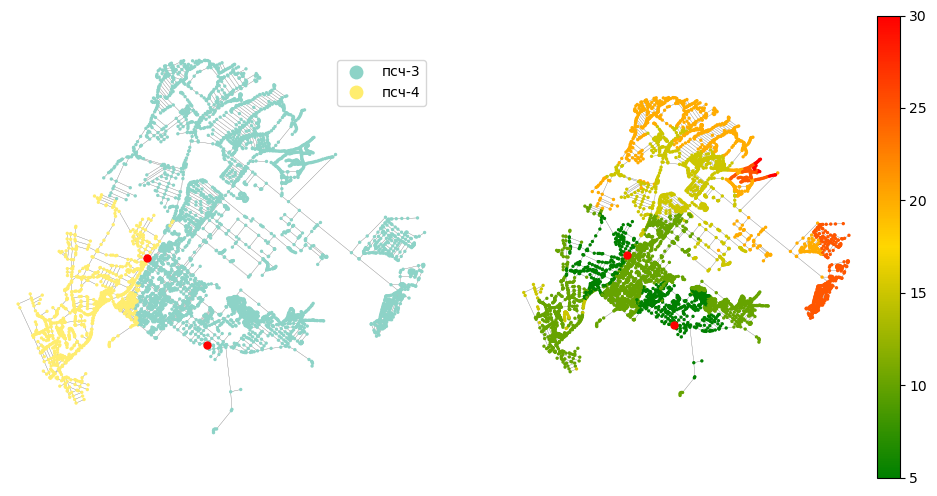

{'best_metric': 10.395688408521078, 'dynamic_nodes': {2760591335: 'псч-3', 4901942432: 'псч-4'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 7.304568733972695, 'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 7.304568733972695, 'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 7.304568733972695, 'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {}}
{'i': 3, 'best_metric': 7.304568733972695, 'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {}}
{'i': 4, 'best_metric': 7.304568733972695, 'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {}}
ВРЕМЯ: 79.49 сек
{'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}}


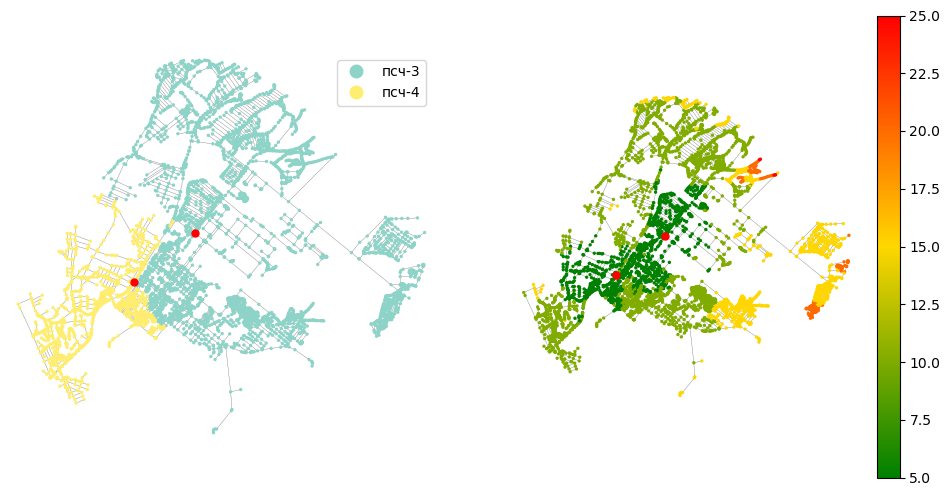

In [22]:
from networkx import MultiDiGraph
from pandas import Series
from genesis.core import MetricBase, StateBase
class BestNodeHillClimbing_maxMean(BestNodeHillClimbing):
    def __init__(self, 
                 state_function: StateBase, 
                 metric_function: MetricBase = None, 
                 appr_val: float = 0.95, 
                 all_nodes: bool = False, 
                 **kwargs) -> None:
        super().__init__(state_function, metric_function, appr_val, all_nodes, **kwargs)
    # def __init__(self, state_function: StateBase, metric_function: MetricBase = None,
    #              appr_val: float = 0.95, **kwargs) -> None:
    #     super().__init__(state_function, metric_function, appr_val, **kwargs)

    def __call__(self, env: MultiDiGraph, 
                 area: Series = None, 
                 start_node: int = None, 
                 debug_route: bool = False, 
                 node_calc_end_function: callable = None, 
                 **kwargs):
        # return super().__call__(env, area, start_node, debug_route, node_calc_end_function, **kwargs)

    # def __call__(self, env: MultiDiGraph, area=None, start_node=None, all_nodes=False, 
    #              debug_route=False, node_calc_end_function=None, **kwargs):
        bnch_max = BestNodeHillClimbing(state_function=self.state_function,
                                        metric_function=ArrivalTime(np.max), appr_val=self.appr_val, all_nodes=self.all_nodes)
        bnch_mean = BestNodeHillClimbing(state_function=self.state_function,
                                         metric_function=ArrivalTime(), appr_val=self.appr_val, all_nodes=self.all_nodes)

        best_node, best_metric = bnch_max(env=env, area=area, start_node=start_node)
        best_node, best_metric = bnch_mean(env=env, area=area, start_node=best_node)
        return best_node, best_metric
    
BNHC_mm = BestNodeHillClimbing_maxMean(state_function=FirstArrivalUnitState())

BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC_mm,
                       appr_val=0.95,
                       iterations=5,
                       ))


iter_state_func(dynamic_nodes=new_units)
optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )
iter_state_func(dynamic_nodes=optimal_nodes)

# Тест-примеры использования

In [3]:
from genesis.mclp import BestNodesKoptG

Расчет размещения 2 подразделений. 

Метрика: **среднее время**

{'dynamic_nodes': {2760591335: 'псч-3', 4901942432: 'псч-4'}}


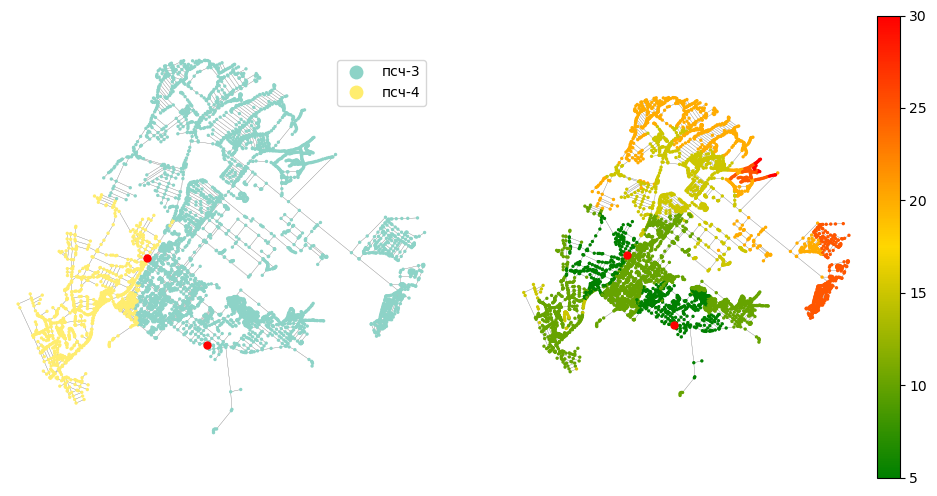

{'best_metric': 10.395688408521078, 'dynamic_nodes': {2760591335: 'псч-3', 4901942432: 'псч-4'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 7.454992334016819, 'dynamic_nodes': {426923808: 'псч-3', 5116722295: 'псч-4'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 7.454992334016819, 'dynamic_nodes': {426923808: 'псч-3', 5116722295: 'псч-4'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 7.454992334016819, 'dynamic_nodes': {426923808: 'псч-3', 5116722295: 'псч-4'}, 'static_nodes': {}}
{'i': 3, 'best_metric': 7.454992334016819, 'dynamic_nodes': {426923808: 'псч-3', 5116722295: 'псч-4'}, 'static_nodes': {}}
{'i': 4, 'best_metric': 7.454992334016819, 'dynamic_nodes': {426923808: 'псч-3', 5116722295: 'псч-4'}, 'static_nodes': {}}
ВРЕМЯ: 22.55 сек
{'dynamic_nodes': {426923808: 'псч-3', 5116722295: 'псч-4'}}


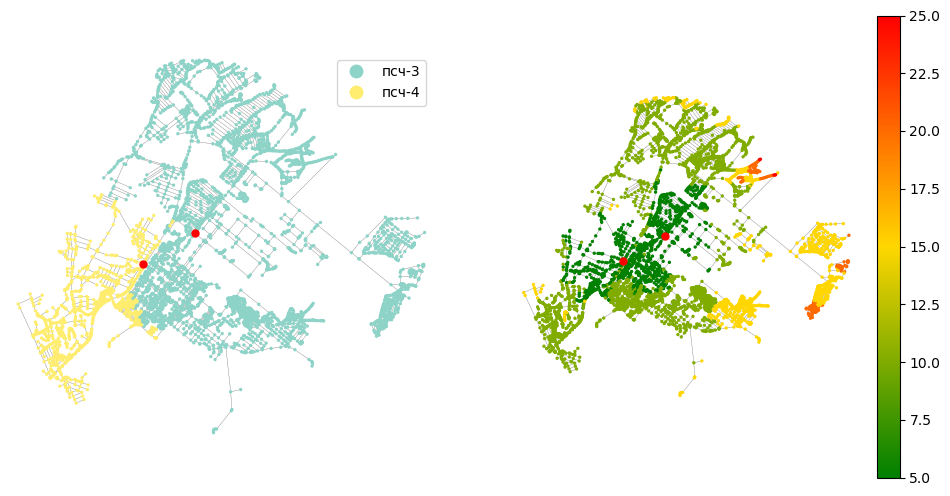

In [15]:
# Перечень узлов
nodes = list(G.nodes())

# Перечень стартовых узлов размещения подразделений
new_units = {
            nodes[3000]:'псч-3',
            nodes[4000]:'псч-4',
            }
# Печать стартового состояния
iter_state_func(dynamic_nodes=new_units)

BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
            metric_function=ArrivalTime())

# Функция расчета лучших размещений. Установка стартовых опций
BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC,
                       ))
# Расчет лучших мест
optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карты итогового размещения
iter_state_func(dynamic_nodes=optimal_nodes)

Расчет размещения 2 подразделений. 

Метрика: **максимальное время**

{'best_metric': 27.880806571428575, 'dynamic_nodes': {2760591335: 'псч-3', 4901942432: 'псч-4'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 17.076365714285714, 'dynamic_nodes': {2034401663: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 16.58431628571429, 'dynamic_nodes': {426923809: 'псч-3', 1296599777: 'псч-4'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 16.58431628571429, 'dynamic_nodes': {426923809: 'псч-3', 1296599777: 'псч-4'}, 'static_nodes': {}}
ВРЕМЯ: 32.61 сек
{'dynamic_nodes': {426923809: 'псч-3', 1296599777: 'псч-4'}}


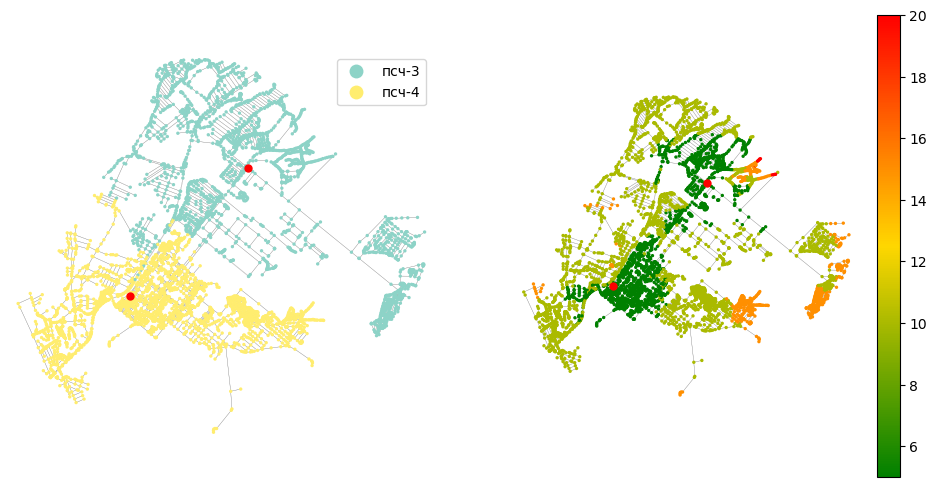

In [16]:
# Функция расчета размещения одного узла в графе. Установка стартовых опций
BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
            metric_function=ArrivalTime(np.max))

# Функция расчета лучших размещений. Установка стартовых опций
BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(np.max),
                       best_point_function=BNHC,
                       iterations=3,
                       ))
# Расчет лучших мест
optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карты итогового размещения
iter_state_func(dynamic_nodes=optimal_nodes)

Расчет размещения 2 подразделений. 

Метрика: **ИП-10**

{'best_metric': 58.41206395348837, 'dynamic_nodes': {2760591335: 'псч-3', 4901942432: 'псч-4'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 62.31831395348837, 'dynamic_nodes': {4116059950: 'псч-3', 5116722296: 'псч-4'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 62.31831395348837, 'dynamic_nodes': {4116059950: 'псч-3', 5116722296: 'псч-4'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 62.31831395348837, 'dynamic_nodes': {4116059950: 'псч-3', 5116722296: 'псч-4'}, 'static_nodes': {}}
{'i': 3, 'best_metric': 62.31831395348837, 'dynamic_nodes': {4116059950: 'псч-3', 5116722296: 'псч-4'}, 'static_nodes': {}}
{'i': 4, 'best_metric': 62.31831395348837, 'dynamic_nodes': {4116059950: 'псч-3', 5116722296: 'псч-4'}, 'static_nodes': {}}
ВРЕМЯ: 7.28 сек
{'dynamic_nodes': {4116059950: 'псч-3', 5116722296: 'псч-4'}}


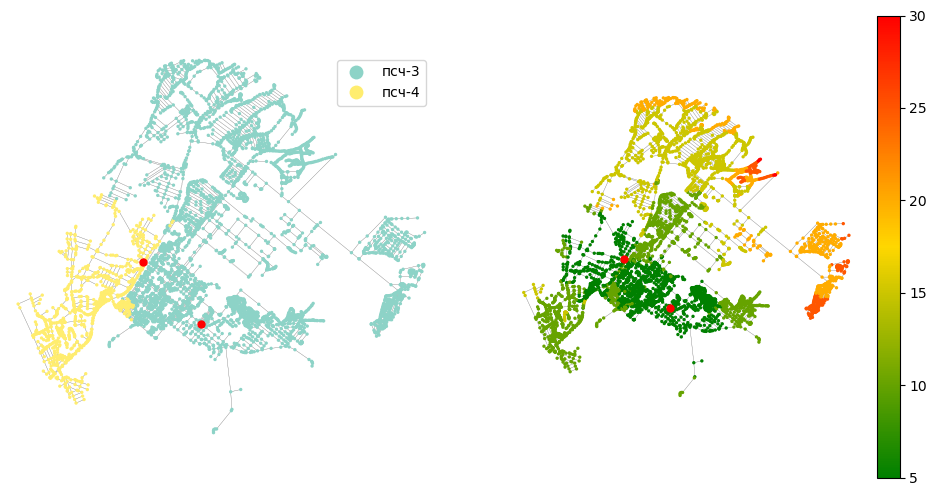

In [17]:
BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=CoverIndex(),
                       )

BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=CoverIndex(),
                       best_point_function=BNHC,
                       iterations=5,
                       ))


# iter_state_func(dynamic_nodes=new_units)
optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )
iter_state_func(dynamic_nodes=optimal_nodes)

Расчет размещения 2 подразделений. 

Метрика: **максимальное время + среднее время**

{'best_metric': 10.395688408521078, 'dynamic_nodes': {2760591335: 'псч-3', 4901942432: 'псч-4'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 7.304568733972695, 'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 7.304568733972695, 'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 7.304568733972695, 'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {}}
ВРЕМЯ: 58.44 сек
{'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}}


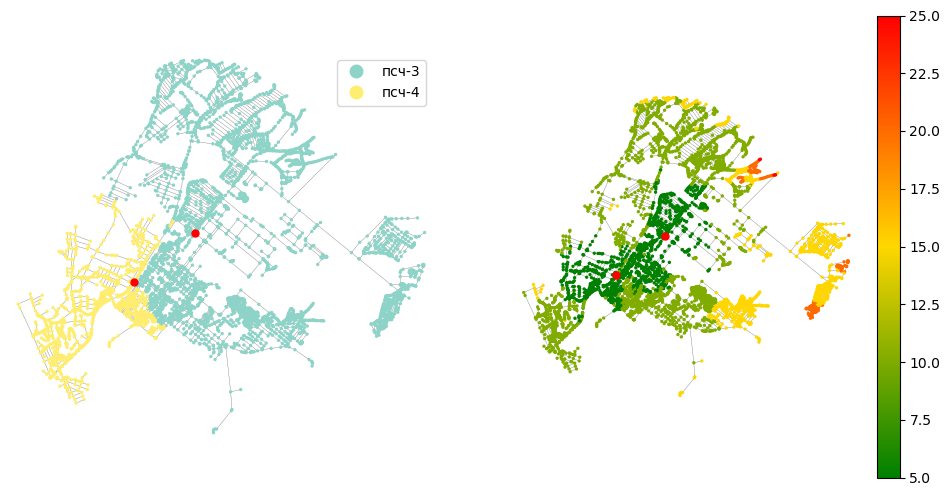

In [23]:
BNHC_mm = BestNodeHillClimbing_maxMean(state_function=FirstArrivalUnitState())

# Функция расчета лучших размещений. Установка стартовых опций
BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC_mm,
                       appr_val=0.95,
                       iterations=3,
                       ))
# Расчет лучших мест
optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карты итогового размещения
iter_state_func(dynamic_nodes=optimal_nodes)

Расчет размещения 2 новых подразделений при наличии 1 существующего.

Метрика: **максимальное время + среднее время**

{'dynamic_nodes': {426923808: 'псч-3', 3119947202: 'псч-4'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}


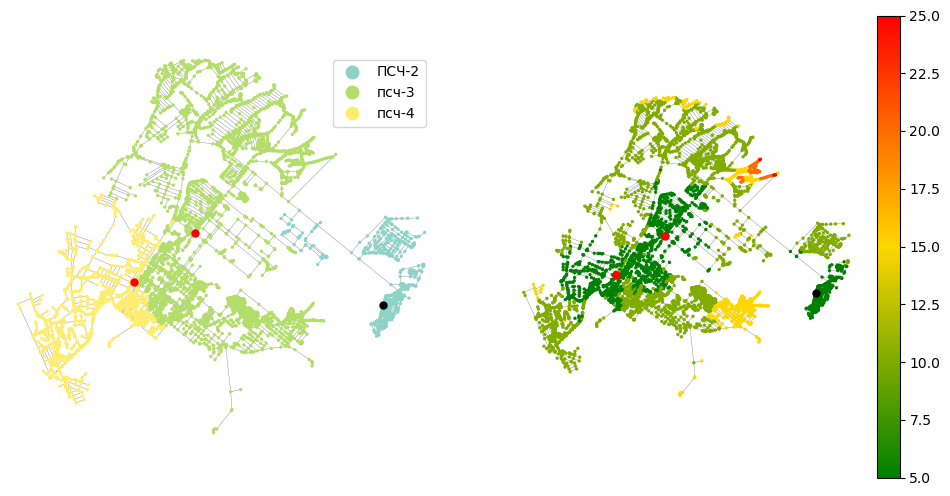

{'best_metric': 8.404563806413517, 'dynamic_nodes': {2760591335: 'новое 1', 4901942432: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
{'i': 0, 'best_metric': 6.536903003984115, 'dynamic_nodes': {426923837: 'новое 1', 3119947202: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
{'i': 1, 'best_metric': 6.40652318712365, 'dynamic_nodes': {426923808: 'новое 1', 3119947202: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
{'i': 2, 'best_metric': 6.40652318712365, 'dynamic_nodes': {426923808: 'новое 1', 3119947202: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
{'i': 3, 'best_metric': 6.40652318712365, 'dynamic_nodes': {426923808: 'новое 1', 3119947202: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
{'i': 4, 'best_metric': 6.40652318712365, 'dynamic_nodes': {426923808: 'новое 1', 3119947202: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
ВРЕМЯ: 66.92 сек
{'dynamic_nodes': {426923808: 'новое 1', 3119947202: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}


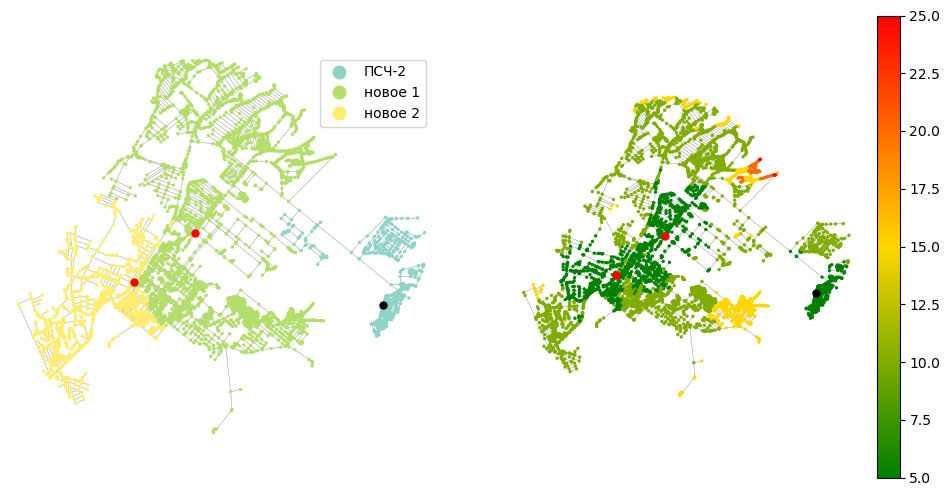

In [24]:
# Словари подразделений
existed_units = {
    nodes[2000]:'ПСЧ-2',
    }
new_units = {
    nodes[3000]:'новое 1',
    nodes[4000]:'новое 2'
    }

# Печать карты стартового размещения
iter_state_func(dynamic_nodes=optimal_nodes, static_nodes=existed_units)

# # Функция расчета лучшего узла. Установка стартовых опций
# BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())
# Функция расчета лучших размещений. Установка стартовых опций
BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC_mm,
                       appr_val=0.95,
                       iterations=5,
                       ))
# Расчет лучших мест
optimal_nodes, best_metric = BNG(env=G,
    static_nodes=existed_units,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карты итогового размещения
iter_state_func(dynamic_nodes=optimal_nodes, static_nodes=existed_units)

Расчет размещения 2 новых подразделений.

Метрика: **максимальное время + среднее время**. Здесь происходит расчет сначала всех подразделений по max потом расчет всех подразделений по mean (бустинг модели?).

Учитывается зона в пределах `area`.

{'best_metric': 6.947033447570087, 'dynamic_nodes': {2760591335: 'новое 1', 4901942432: 'новое 2'}, 'static_nodes': {}}
ВРЕМЯ: 22.49 сек
{'best_metric': 4.350491521585032, 'dynamic_nodes': {4116030638: 'новое 1', 3114758150: 'новое 2'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 3.678390398205505, 'dynamic_nodes': {1297036351: 'новое 1', 5574240399: 'новое 2'}, 'static_nodes': {}}
ВРЕМЯ: 8.39 сек
{'dynamic_nodes': {1297036351: 'новое 1', 5574240399: 'новое 2'}}


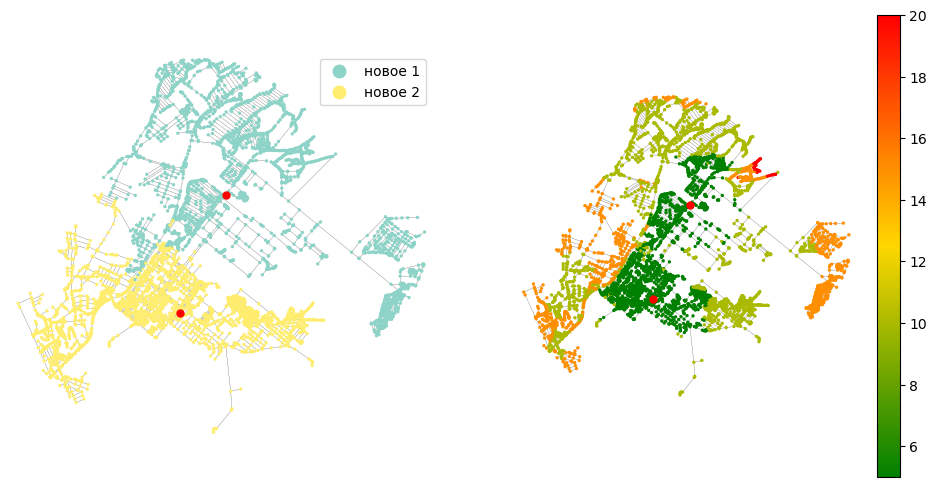

In [25]:
# Определение маски расчета
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)

# Узлы графа УДС
nodes = list(G.nodes())

# Словари подразделений
# Существующие
existed_units = {
    # nodes[2000]:'ПСЧ-2',
    }
# Новые
new_units = {
    nodes[3000]:'новое 1',
    nodes[4000]:'новое 2'
    }

# Функции расчета лучшего узла. Установка стартовых опций
BNF_max = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max))  #, appr_val=0)
BNF_mean = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max))  #, appr_val=0)
# Функции расчета лучших размещений. Установка стартовых опций
BNG_max = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNF_max,
                       iterations=1,
                       ))
BNG_mean = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNF_mean,
                       iterations=1,
                       ))
# Расчет лучших мест
optimal_nodes, best_metric = BNG_max(env=G,
    # static_nodes=existed_units,
    dynamic_nodes=new_units,
    area=points_mask,
    before_iters_start_function=iter_func,
    # iter_calc_end_function=iter_func,
    )
optimal_nodes, best_metric = BNG_mean(env=G,
    # static_nodes=existed_units,
    dynamic_nodes=optimal_nodes,
    area=points_mask,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карты итогового размещения
iter_state_func(dynamic_nodes=optimal_nodes)

<Axes: >

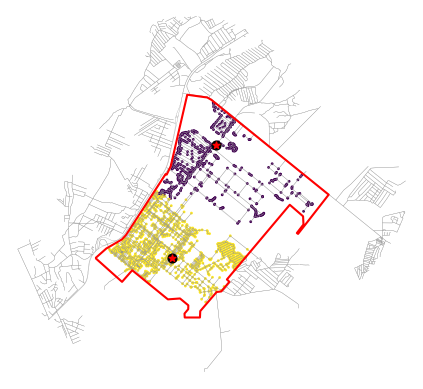

In [26]:
ns = ox.graph_to_gdfs(G, edges=False)
points_mask = ns.within(area.iloc[0].geometry)

times, nearest = FirstArrivalUnitState()(env=G, points=list(optimal_nodes.keys()), area=points_mask)

ns['nearest'] = nearest


ax = ns[ns['nearest'].notna()].plot(markersize=1, column='nearest')
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax)
area.boundary.plot(ax=ax, color='r')
ns.loc[optimal_nodes.keys()].plot(ax=ax, markersize=40, color='k')
ns.loc[optimal_nodes.keys()].plot(ax=ax, markersize=25, color='red', marker="*")

Расчет размещения 2 новых подразделений при наличии 1 существующего.

Метрика: **максимальное время + среднее время**. Здесь происходит расчет сначала всех подразделений по max потом расчет ссех подразделений по mean (бустинг модели?).

Учитывается зона в пределах `area`.

Считается 3 итерации max + 3 итерации mean.

{'dynamic_nodes': {2760591335: 'новое 1', 4901942432: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}


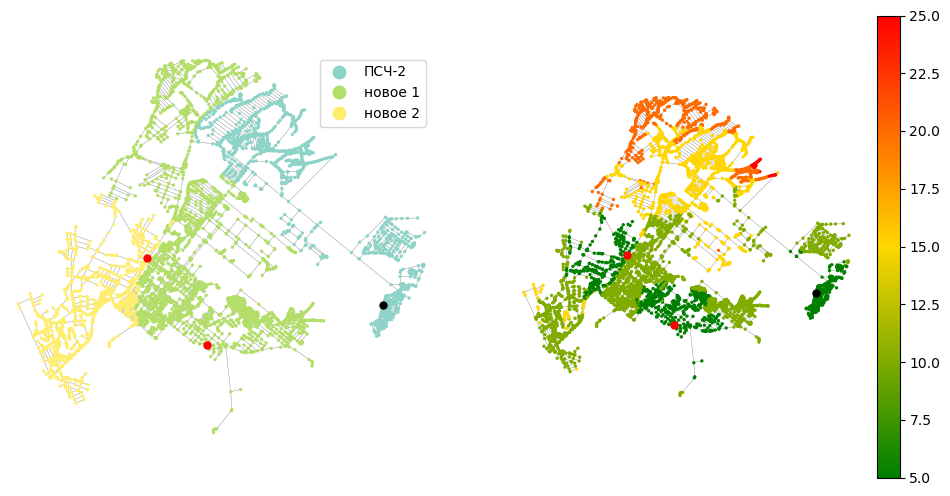

{'i': 0, 'best_metric': 4.142160935596143, 'dynamic_nodes': {6222357764: 'новое 1', 3114758150: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
{'i': 1, 'best_metric': 4.101862443738425, 'dynamic_nodes': {6222357764: 'новое 1', 8922727824: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
{'i': 2, 'best_metric': 3.6711447490580498, 'dynamic_nodes': {10044183491: 'новое 1', 5574240399: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
ВРЕМЯ: 21.61 сек
{'dynamic_nodes': {10044183491: 'новое 1', 5574240399: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}


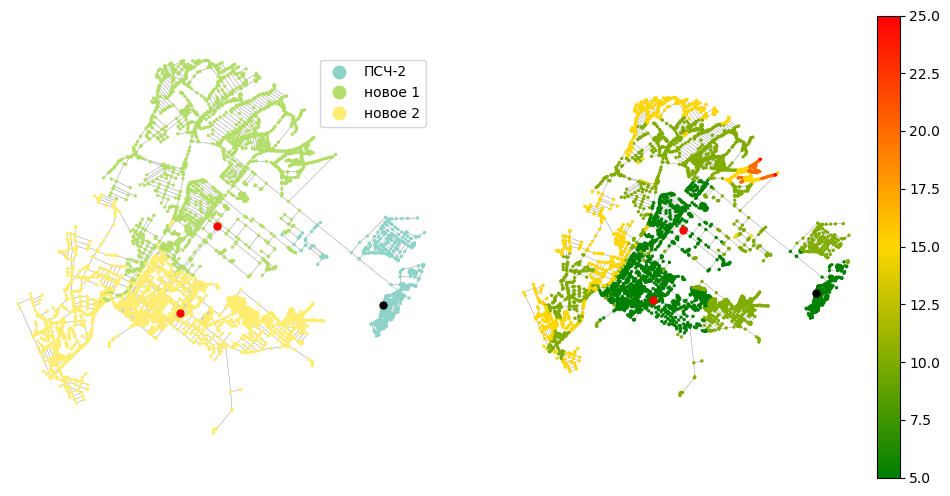

{'best_metric': 3.6711447490580498, 'dynamic_nodes': {10044183491: 'новое 1', 5574240399: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}
ВРЕМЯ: 7.71 сек
{'dynamic_nodes': {2034401374: 'новое 1', 1577701962: 'новое 2'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}


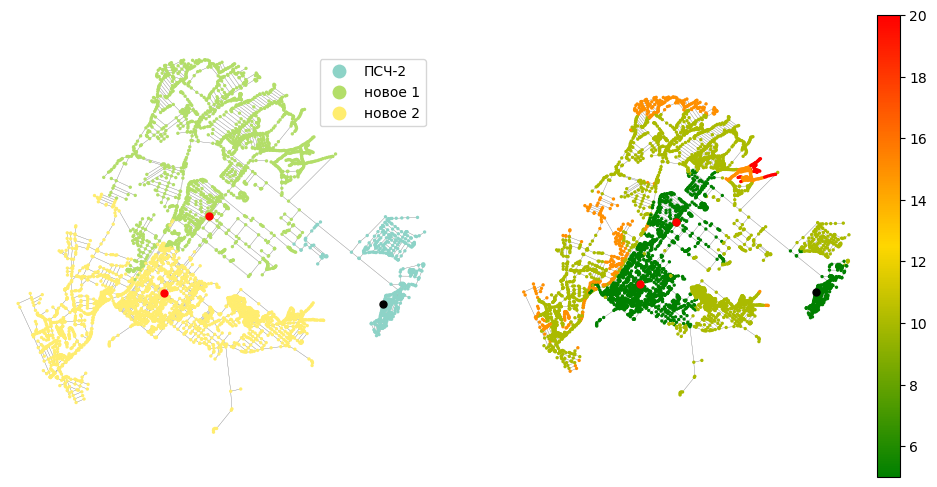

In [27]:
# Определение маски расчета
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)

# Узлы графа УДС
nodes = list(G.nodes())

# Словари подразделений
# Существующие
existed_units = {
    nodes[2000]:'ПСЧ-2',
}
# Новые
new_units = {
    nodes[3000]:'новое 1',
    nodes[4000]:'новое 2'
}

iter_state_func(dynamic_nodes=new_units, static_nodes=existed_units)

# Функции расчета лучшего узла. Установка стартовых опций
BNF_max = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(np.max), appr_val=0)
BNF_mean = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(), appr_val=0)
# Функции расчета лучших размещений. Установка стартовых опций
BNG_max = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(np.mean),
                       best_point_function=BNF_max,
                       iterations=3,
                       ))
BNG_mean = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(np.mean),
                       best_point_function=BNF_mean,
                       iterations=3,
                       ))
# Расчет лучших мест
optimal_nodes, best_metric = BNG_max(env=G,
    static_nodes=existed_units,
    dynamic_nodes=new_units,
    area=points_mask,
    # before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )
iter_state_func(dynamic_nodes=optimal_nodes, static_nodes=existed_units)
optimal_nodes, best_metric = BNG_mean(env=G,
    static_nodes=existed_units,
    dynamic_nodes=optimal_nodes,
    area=points_mask,
    before_iters_start_function=iter_func,
    # iter_calc_end_function=iter_func,
    )

# Печать карты итогового размещения
iter_state_func(dynamic_nodes=optimal_nodes, static_nodes=existed_units)

<Axes: >

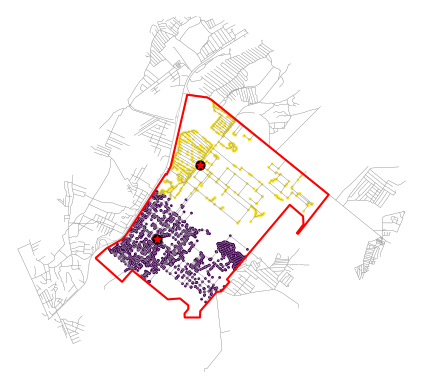

In [28]:
ns = ox.graph_to_gdfs(G, edges=False)
points_mask = ns.within(area.iloc[0].geometry)

times, nearest = FirstArrivalUnitState()(env=G, points=list(optimal_nodes.keys()), area=points_mask)

ns['nearest'] = nearest

ax = ns[ns['nearest'].notna()].plot(markersize=1, column='nearest')
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax)
area.boundary.plot(ax=ax, color='r')
ns.loc[optimal_nodes.keys()].plot(ax=ax, markersize=40, color='k')
ns.loc[optimal_nodes.keys()].plot(ax=ax, markersize=25, color='red', marker="*")

In [16]:
ns.to_file(r'tests\data\t.gpkg')

In [17]:
units = ns.loc[optimal_nodes.keys()].copy()
units['unit'] = optimal_nodes
units.to_file(r'tests\data\unit_t.gpkg')

## Проблема

Подразделение "новое 2" не заходит внутрь зоны area, хотя по логике должно. Скорее всего вычисляется метрика для всего подграфа.

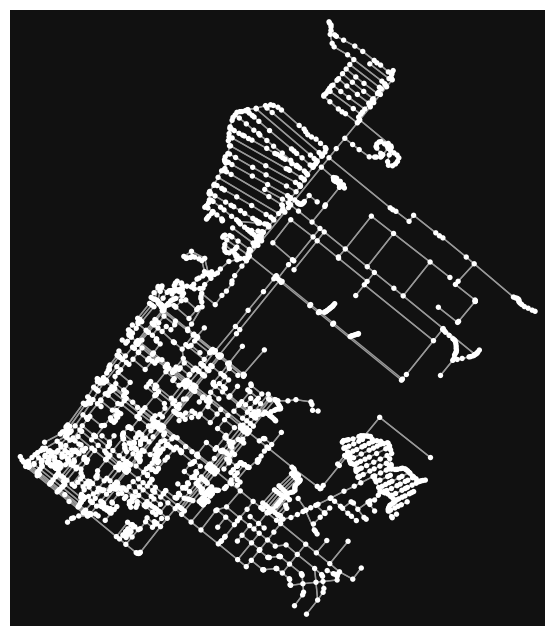

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [18]:
GG = ox.truncate.truncate_graph_polygon(G, area.geometry.iloc[0])
ox.plot_graph(GG)

### Рассмотреть в работе!

Здесь локальные оптимумы...

{'best_metric': 4.111567542169069, 'dynamic_nodes': {1545616091: 'a', 1552046387: 'b'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 3.697298005799476, 'dynamic_nodes': {426923846: 'a', 1555142677: 'b'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 3.533418940399738, 'dynamic_nodes': {426923846: 'a', 426923792: 'b'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 3.2956131199541283, 'dynamic_nodes': {426923855: 'a', 2034401362: 'b'}, 'static_nodes': {}}
{'i': 3, 'best_metric': 3.223170284370904, 'dynamic_nodes': {1577701962: 'a', 2034401374: 'b'}, 'static_nodes': {}}
{'i': 4, 'best_metric': 3.223170284370904, 'dynamic_nodes': {1577701962: 'a', 2034401374: 'b'}, 'static_nodes': {}}
ВРЕМЯ: 20.3 сек
{'dynamic_nodes': {1577701962: 'a', 2034401374: 'b'}, 'static_nodes': {2042076750: 'ПСЧ-2'}}


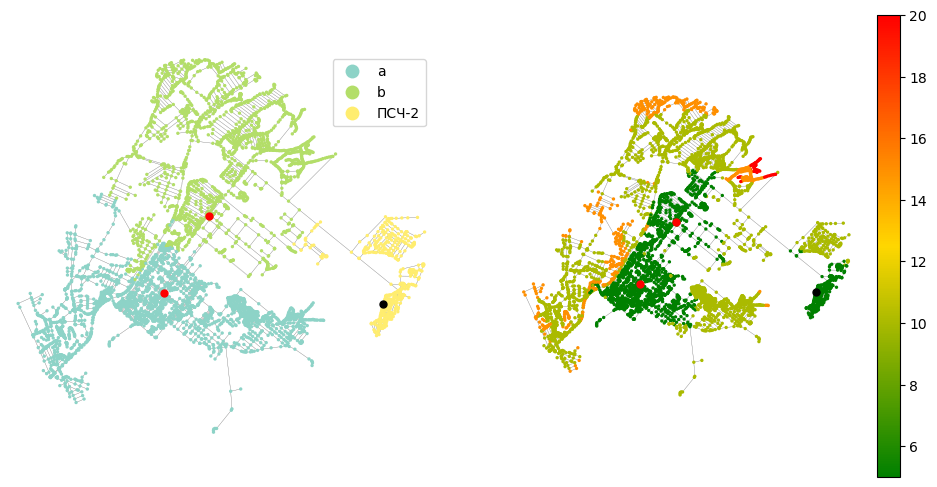

In [19]:
nds = list(GG.nodes())
test_nodes = {
    nds[100]:'a',
    nds[200]:'b',
}

# Расчет лучших мест
optimal_nodes, best_metric = BNG(env=GG,
    # static_nodes=existed_units,
    dynamic_nodes=test_nodes,
    # area=points_mask,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карты итогового размещения
iter_state_func(dynamic_nodes=optimal_nodes, static_nodes=existed_units)

Решено за счет применения последовательного расчета метриками max+mean.

Нужно проверить как изменятся результаты для двух способов расчета:

1. Сначала полностью рассчитывается max, потом полностью рассчитывается mean.
2. Расчет осуществляется попеременно max/mean, на протяжении нескольких итераций.